### You can run this notebook at Colab by clicking here:

<a target="_blank" href="https://colab.research.google.com/github/NMRLipids/databank-template/blob/main/scripts/plotQuality.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Initialize FAIRMD Lipids databank

In [1]:
import os
import sys
import subprocess

# This installs FAIRMD Lipids databank tools on Colab and initializes data.
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "fairmd-lipids"], check=True)
    subprocess.run(["fmdl_initialize_data", "stable"], check=True)

    # Load environment variables from databank_env.rc into this Python process.
    with open("databank_env.rc") as env_file:
        for line in env_file:
            line = line.strip()
            if line.startswith("export ") and "=" in line:
                key, value = line[len("export "):].split("=", 1)
                os.environ[key] = value

# On local machine, set FMDL_DATA_PATH to the initialized databank folder.
# Optionally set FMDL_SIMU_PATH if your simulations are in a non-default location.
# os.environ["FMDL_DATA_PATH"] = "/path/to/your/BilayerData"

In [8]:
import random

# Core FAIRMD Lipids routines and API
from fairmd.lipids.core import initialize_databank, print_README
from fairmd.lipids.api import (
    get_mean_ApL,
    get_thickness,
    get_eqtimes,
    UniverseConstructor,
    mda_read_trj_tilt_angles,
    lipids_set,
    )


# Initialize the databank and load all simulations.
systems = initialize_databank()

Simulations are initialized from the folder: /home/hsantila/fairMD_DB/BilayerData/Simulations


# Select random simulation for example and show its content

In [10]:
# To exemplify the analysis of any simulation, we select one random simulation ID
randomID = None
while randomID is None:
    _rid = random.randint(1, len(systems))
    try:
        system = systems.loc(_rid)
        randomID = _rid
    except KeyError:
        pass

print('ID of the selected simulation: ', randomID)

# Get system by ID and print metadata
system = systems.loc(randomID)
print_README(system)

ID of the selected simulation:  30
DOI:
  10.5281/zenodo.30898
DATE:
  2015-09-11
SOFTWARE:
  gromacs
TRJ:
  [['0m_popc_amb_100_200ns.xtc']]
TPR:
  [['run_200ns_gpu.tpr']]
PREEQTIME:
  105
TIMELEFTOUT:
  0
COMPOSITION:
  {'POPC': {'NAME': 'POPC', 'MAPPING': 'mappingPOPClipid14_POPCres.yaml', 'COUNT': [64, 64]}, 'SOL': {'NAME': 'SOL', 'MAPPING': 'mappingTIP3Pwater.yaml', 'COUNT': 5120}}
DIR_WRK:
  /usr/home/bort/Databank
PUBLICATION:
  None
AUTHORS_CONTACT:
  Girych Mykhailo; Ollila O. H. Samuli
SYSTEM:
  128POPC_5120SOL_298K
SOFTWARE_VERSION:
  5.0.3
FF:
  Lipid14 with Verlet scheme
FF_SOURCE:
  None
FF_DATE:
  None
CPT:
  None
LOG:
  None
TOP:
  [['topol.top']]
TRAJECTORY_SIZE:
  1205630200
TRJLENGTH:
  100010.0
TEMPERATURE:
  298.15
NUMBER_OF_ATOMS:
  32512
DATEOFRUNNING:
  03/01/2022
TYPEOFSYSTEM:
  lipid bilayer
EXPERIMENT:
  {'ORDERPARAMETER': {'POPC': ['10.1021/acs.jpcb.4c04719/4', '10.1039/c2cp42738a/1']}, 'FORMFACTOR': ['10.1021/acs.jctc.3c00648/1']}
ID:
  30
path:
  eba/d7b/eb

# Show analyzed properties stored in FAIRMD Lipids for the selected system

Membrane area per lipid: 63.308657574242574 

Membrane thickness: 4.156642211914063 

Relative equilibration time for each lipid in the simulation: 
{'POPC': 4.711643283658896}


Plot form factor and C-H bond order parameters from the simulation together with experimental data if available 

POPC
DOI: 10.5281/zenodo.30898
Form factor quality: 0.2666
Using FF scale 74.93 from experiment 10.1021/acs.jctc.3c00648/1.


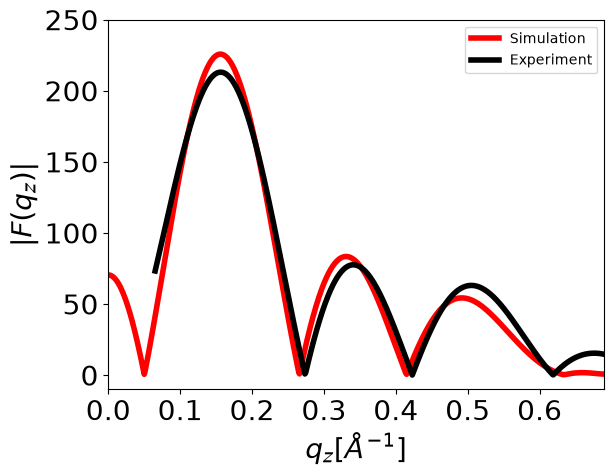

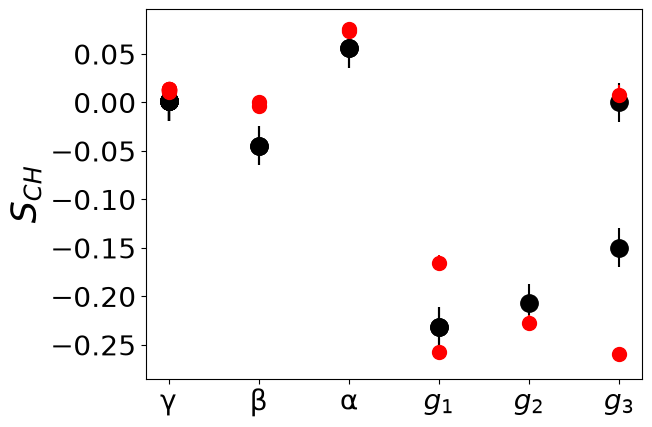

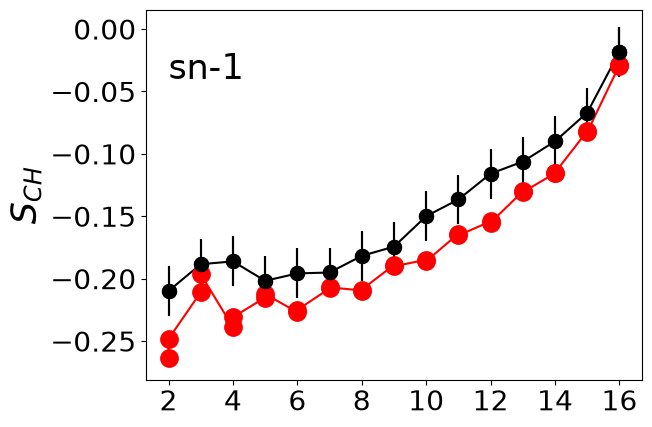

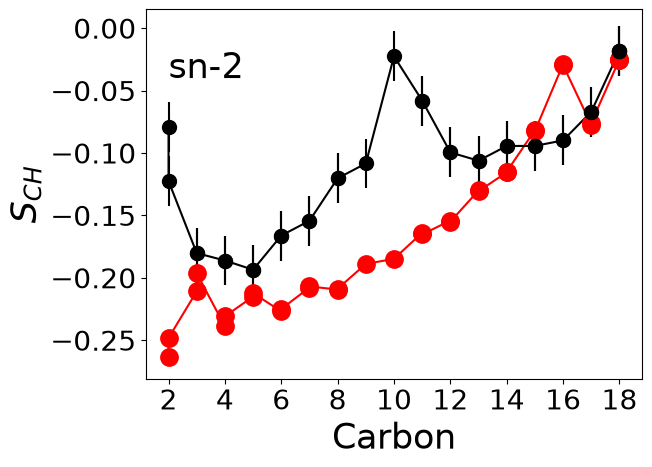

In [11]:
## Membrane area per lipid, thickness, relative equilibration time, C-H bond order parameters
## and X-ray scattering form factors shown for the selected random simulation.
from plot_tools import plotSimulation
try:
    APL = get_mean_ApL(system)
    print('Membrane area per lipid:', APL, '\n')
except Exception:
    print('Membrane area per lipid: not available\n')

try:
    thickness = get_thickness(system)
    print('Membrane thickness:', thickness, '\n')
except Exception:
    print('Membrane thickness: not available\n')

print('Relative equilibration time for each lipid in the simulation: ')
try:
    print(get_eqtimes(system))
except Exception:
    print('Not available')
print('\n')

print('Plot form factor and C-H bond order parameters from the simulation together with experimental data if available \n')
for lipid in system.lipids:
    print(lipid)
    try:
        plotSimulation(system, lipid)
    except Exception as e:
        print('Plotting failed for', lipid)
        print(e)

# Selects a random simulation with the trajectory size below 100Mb and calculates P-N vector angle with respect to membrane normal for all lipids for which P and N atoms are available in headgroup

In [12]:
systems.loc(756)

System(756): 30e/6ee/30e6eedb46c2d313b709697ae73f0671c5079dc6/7aac3f64c8467f18f5265bc5aa63ed6895c348cf

In [16]:
# Universal atom names for phosphate and nitrogen headgroup atoms
Patom_UNI = 'M_G3P2_M'
Natom_UNI = 'M_G3N6_M'

# Find a random simulation with trajectory smaller than 100 MB
for _ in range(len(systems)):
    randomID = random.randint(1, len(systems))
    try:
        system = systems.loc(randomID)
    except KeyError:
        continue
    try:
        traj_size=system['TRAJECTORY_SIZE']
        if traj_size < 100000000:
            break
        else:
            continue
    except:
        continue

print('ID number of the selected simulation: ', randomID)

# Create MDAnalysis Universe from the selected simulation
uc = UniverseConstructor(system)
uc.download_mddata()
MDAuni = uc.build_universe()

# Loop over lipids and calculate P-N vector angle if atoms are found in mapping
for molecule in system.lipids:
    print('\n Analysing ' + molecule)
    try:
        p_sel = system.content[molecule].uan2selection(Patom_UNI, system['COMPOSITION'][molecule]['NAME'])
        n_sel = system.content[molecule].uan2selection(Natom_UNI, system['COMPOSITION'][molecule]['NAME'])
        Patom_SIM = MDAuni.select_atoms(p_sel).atoms.names[0]
        Natom_SIM = MDAuni.select_atoms(n_sel).atoms.names[0]
    except Exception:
        print('P or N atom mapping was not found for', molecule)
        continue

    resname = system['COMPOSITION'][molecule]['NAME']
    PNangles = mda_read_trj_tilt_angles(resname, Patom_SIM, Natom_SIM, MDAuni)

    print('PN vector angle for ' + molecule + ':' + str(PNangles[2]) + ' +/- ' + str(PNangles[3]) + '\n')

ID number of the selected simulation:  676
DOPC_s.tpr: 100%|████████████████████████████| 735k/735k [00:03<00:00, 230kB/s]
DOPC_s.xtc: 100%|█████████████████████████| 63.9M/63.9M [00:18<00:00, 3.55MB/s]

 Analysing DOPC
PN vector angle for DOPC:69.8419693955639 +/- 0.17289164031832657

